# Práctica 1: Exploración de Niveles del Lenguaje

**Nombre:** Omar Fernando Gramer Muñoz<br>
**Materia:** Lingüística Computacional<br>
**Matrícula:** 419003698

In [1]:
# Importaciones
import http
from collections import defaultdict

import pandas as pd
import requests as r

from rich import print as rprint
from rich.columns import Columns
from rich.panel import Panel
from rich.text import Text

import re

import matplotlib.pyplot as plt
import nltk
import pandas as pd
import requests as r
from nltk.corpus import cess_esp

from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn_crfsuite import CRF



## **Fonética**
___

#### **Con base en el sistema de búsqueda visto en la práctica 1 dónde se recibe una palabra ortográfica y devuelve sus transcripciones fonológicas, proponga una solución para los casos en que la palabra buscada no se encuentra en el lexicón/diccionario**

### **¿Cómo devolver o aproximar su transcripción fonológica?**

El sistema de búsqueda de la práctica devuelve una lista vacía cuando 
la palabra no existe en el lexicón. 

Una alternativa para que esto no ocurra es aprovechar que el español 
tiene una correspondencia **grafema-fonema muy regular** pues en la 
mayoría de los casos, sabemos exactamente cómo pronunciar una letra según su contexto. 
A diferencia del inglés donde "gh" puede sonar como 'f' (enough), 'ɡ' (ghost) o 
ser muda (night), el español sigue reglas mucho más predecibles.

Usando esto podemos construir un sistema **G2P (Grapheme-to-Phoneme)**:
que es un conjunto ordenado de reglas que convierte secuencias de letras en 
símbolos IPA. Las reglas más específicas (dígrafos como "ch", "ll", 
"rr") se aplican antes que las individuales para evitar ambigüedades.

**Entonces la estrategía será:**

1. Buscar la palabra en el lexicón (comportamiento original)
2. Si se encuentra entonces devolver la transcripción validada
3. Si no se encuentra aplicar las reglas G2P para generar 
   una transcripción aproximada

De esta forma el sistema nunca devuelve una lista vacía.

In [2]:
IPA_URL = "https://raw.githubusercontent.com/open-dict-data/ipa-dict/master/data/{lang}.txt"

In [3]:
# Funciones de descarga y parseo del dataset ( tomadas del notebook de la clase )
def download_ipa_corpus(iso_lang: str) -> str:
    print(f"Downloading {iso_lang}", end="::")
    response = r.get(IPA_URL.format(lang=iso_lang))
    status_code = response.status_code
    print(f"status={status_code}")
    if status_code != http.HTTPStatus.OK:
        print(f"ERROR on {iso_lang} :(")
        return ""
    return response.text

def parse_response(response: str) -> dict:
    ipa_list = response.rstrip().split("\n")
    result = {}
    for item in ipa_list:
        if item == '':
            continue
        item_list = item.split("\t")
        result[item_list[0]] = item_list[1]
    return result

In [4]:
# Descargar el dataset de español mexicano
dataset_es_mx = parse_response(download_ipa_corpus("es_MX"))

In [5]:
# Obviamente utlicé Claude para esto a nivel de 'Delegación supervisada', 
# no hay forma de que escribiera estas reglas a mano sin que se me escapara alguna o estuvieran completamente correctas.
# Desde luego que reviso el código, lo entiendo y hago las modificaciones que sienta pertinentes.

# Reglas grafema → fonema para español mexicano
# Se aplican en orden (las más específicas primero)
def g2p_es(word: str) -> str:
    text = word.lower()
    result = ""
    i = 0
    while i < len(text):
        char = text[i]
        next_char = text[i+1] if i+1 < len(text) else ""
        
        # Dígrafos (verificar primero)
        digraph = char + next_char
        if digraph == "ch":
            result += "tʃ"; i += 2
        elif digraph == "ll":
            result += "ʝ"; i += 2
        elif digraph == "rr":
            result += "r"; i += 2
        elif digraph == "qu":
            result += "k"; i += 2
        elif digraph in ("ge", "gi"):
            result += "x"; i += 1  # solo consumimos g, la vocal sigue
        elif digraph in ("gue", "gui"):
            result += "ɡ"; i += 2
        
        # Reglas contextuales para 'c'
        elif char == "c" and next_char in ("e", "i"):
            result += "s"; i += 1  # ce, ci → s
        elif char == "c":
            result += "k"; i += 1  # ca, co, cu → k
        
        # Reglas contextuales para 'g'
        elif char == "g" and next_char in ("e", "i"):
            result += "x"; i += 1  # ge, gi → x
        elif char == "g":
            result += "ɡ"; i += 1  # ga, go, gu → ɡ
        
        # Reglas simples
        elif char == "h":
            i += 1  # muda
        elif char == "j":
            result += "x"; i += 1
        elif char == "r" and i == 0:
            result += "r"; i += 1  # r inicial es vibrante múltiple
        elif char == "r":
            result += "ɾ"; i += 1  # r intervocálica es vibrante simple
        elif char == "ñ":
            result += "ɲ"; i += 1
        elif char in ("b", "v"):
            result += "β"; i += 1
        elif char == "y":
            result += "ʝ"; i += 1
        elif char == "z":
            result += "s"; i += 1
        elif char == "x":
            result += "ks"; i += 1
        else:
            # Vocales y consonantes directas
            direct = {"a":"a","e":"e","i":"i","o":"o","u":"u",
                      "á":"a","é":"e","í":"i","ó":"o","ú":"u",
                      "p":"p","t":"t","k":"k","f":"f","s":"s",
                      "l":"l","m":"m","n":"n","d":"ð","w":"w"}
            result += direct.get(char, char)
            i += 1
    
    return f"/{result}/"

### **Reutiliza el sistema de búsqueda visto en clase y mejóralo con esta funcionalidad**

In [6]:
def get_ipa_transcriptions_improved(word: str, dataset: dict) -> tuple[list[str], str]:
    """
    Versión mejorada del sistema de búsqueda.
    
    Primero busca en el lexicón. Si no encuentra la palabra,
    genera una transcripción aproximada con reglas G2P.
    
    Parameters
    ----------
    word : str
        Palabra a buscar
    dataset : dict
        Diccionario IPA del idioma
    
    Returns
    -------
    tuple[list[str], str]
        (transcripciones, fuente) donde fuente es 
        'lexicon' o 'g2p'
    """
    result = dataset.get(word.lower(), "")
    if result:
        return result.split(", "), "lexicon"
    else:
        return [g2p_es(word)], "g2p"

### **Muestra al menos tres ejemplos**

In [7]:
# ============================================================
# Ejemplos de uso del sistema mejorado
# ============================================================

test_words = [
    # Palabra conocida (en lexicón)
    "mayonesa",
    # Palabra derivada
    "mayonesita",
    # Neologismo (OOV)
    "tuitear",
    # Nombre propio (OOV)
    "xochimilco",
    # Palabra con ortografía especial (OOV)
    "whatsappear",
    # Conocida
    "corazón",
    # Nombre propio (OOV)
    "tlalpan",
    # Neologismo (OOV)
    "googlear",
    # Palabra conocida
    "chatear",
    # Neologismo (OOV)
    "chatgptear",
    # Palabra conocida
    "muchacho",
    # Me la inventé
    "muchachismo"
]

print("=" * 55)
print(f"{'Palabra':<15} {'Transcripción':<20} {'Fuente'}")
print("=" * 55)

for word in test_words:
    transcriptions, source = get_ipa_transcriptions_improved(word, dataset_es_mx)
    icon = "📖" if source == "lexicon" else "🔧"
    print(f"{word:<15} {', '.join(transcriptions):<20} {icon} {source}")

print("=" * 55)

Palabra         Transcripción        Fuente
mayonesa        /maʝonesa/           📖 lexicon
mayonesita      /maʝonesita/         🔧 g2p
tuitear         /tuiteaɾ/            🔧 g2p
xochimilco      /ksotʃimilko/        🔧 g2p
whatsappear     /watsappeaɾ/         🔧 g2p
corazón         /koɾaˈson/           📖 lexicon
tlalpan         /tlalpan/            🔧 g2p
googlear        /ɡooɡleaɾ/           🔧 g2p
chatear         /tʃateaɾ/            📖 lexicon
chatgptear      /tʃatɡpteaɾ/         🔧 g2p
muchacho        /mutʃatʃo/           📖 lexicon
muchachismo     /mutʃatʃismo/        🔧 g2p


## **Morfología**
***

### **Elige tres lenguas del corpus que pertenezcan a familias lingüísticas distintas**

Eligí las siguientes tres lenguas:

| Lengua   | Familia              | Código |
|----------|----------------------|--------|
| Russian  | Baltoeslava (Indo-Europea)| `rus`  |
| Húngaro  | Urálica              | `hun`  |
| Francés  | Romance (Indo-Europea)| `fra` |

In [8]:
langs_selected = {
    "rus": "Russian",
    "hun": "Hungarian",
    "fra": "French",
}

In [9]:
# Constantes y funciones tomadas del notebook niveles linguisticos 2 
CATEGORIES = {
    "100": "Inflection",
    "010": "Derivation",
    "101": "Inflection, Compound",
    "000": "Root",
    "011": "Derivation, Compound",
    "110": "Inflection, Derivation",
    "001": "Compound",
    "111": "Inflection, Derivation, Compound"
}


def get_track_files(lang: str, track: str = "word") -> list[str]:
    """Genera una lista de nombres de archivo del shared task."""
    return [
        f"{lang}.{track}.test.gold",
        f"{lang}.{track}.dev",
    ]

def get_raw_corpus(files: list) -> list:
    """Descarga y concatena los datos de los archivos tsv desde GitHub."""
    result = []
    for file in files:
        print(f"Downloading {file}.tsv", end=" ")
        response = r.get(
            f"https://raw.githubusercontent.com/sigmorphon/2022SegmentationST/main/data/{file}.tsv"
        )
        print(f"status={response.status_code}")
        lines = response.text.split("\n")
        result.extend(lines[:-1])
    return result

def raw_corpus_to_dataframe(corpus_list: list, lang: str) -> pd.DataFrame:
    """Convierte una lista de datos de corpus en un DataFrame."""
    data_list = []
    for line in corpus_list:
        try:
            word, tagged_data, category = line.split("\t")
        except ValueError:
            word, tagged_data = line.split("\t")
            category = "NOT_FOUND"
        morphemes = tagged_data.split()
        data_list.append(
            {"words": word, "morph": morphemes, "category": category, "lang": lang}
        )
    df = pd.DataFrame(data_list)
    df["word_len"] = df["words"].apply(lambda word: len(word))
    df["morph_count"] = df["morph"].apply(lambda lst: len(lst))
    return df

In [10]:
# Descargamos los tres corpus
corpora_morph = {}
for code, name in langs_selected.items():
    files = get_track_files(code)
    raw = get_raw_corpus(files)
    corpora_morph[code] = raw_corpus_to_dataframe(raw, lang=code)
    print(f"{name}: {len(corpora_morph[code])} entradas\n")

Russian: 156846 entradas

Hungarian: 188074 entradas

French: 63173 entradas



In [11]:
corpora_morph['fra'].head(10)

,words,morph,category,lang,word_len,morph_count
0,marreront,"[marre, @@er, @@eront]",110,fra,9,3
1,dégueulais,"[dé, @@gueule, @@er, @@ais]",110,fra,10,4
2,fantasmons,"[fantasme, @@er, @@ons]",110,fra,10,3
3,Grainvillois,"[Grainville, @@ois]",010,fra,12,2
4,confirais,"[confire, @@irais]",100,fra,9,2
5,dessellait,"[dé, @@selle, @@er, @@ait]",110,fra,10,4
6,hydrodynamique,"[hydro, @@dynamique]",010,fra,14,2
7,konzo,[konzo],000,fra,5,1
8,postillonnerions,"[postillon, @@er, @@erions]",110,fra,16,3
9,reportât,"[re, @@porter, @@ât]",110,fra,8,3


### **Para cada una de las tres lenguas calcula y compara:**

- **Ratio morfemas / palabra: El promedio de morfemas que componen las palabras**
- **Indicé de Flexión / Derivación: Del total de morfemas, ¿Qué porcentaje son etiquetas de flexión (100) y cuáles de derivación (010)?**


In [12]:
def morphological_metrics(df: pd.DataFrame, lang_name: str) -> dict:
    """
    Calcula métricas morfológicas para un corpus convertido en dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame con columnas 'morph' y 'category'
    lang_name : str
        Nombre de la lengua

    Returns
    -------
    dict
        Métricas calculadas
    """
    total = len(df)

    # Ratio morfemas / palabra
    morph_ratio = df["morph_count"].mean()

    # Flexión: categoría 100
    flexion    = df[df["category"] == "100"].shape[0]

    # Derivación: categoría 010
    derivation    = df[df["category"] == "010"].shape[0]

    pct_flexion    = (flexion / total) * 100
    pct_derivation = (derivation / total) * 100

    return {
        "Lengua":               lang_name,
        "Total palabras":       total,
        "Morfemas/palabra (μ)": round(morph_ratio, 3),
        "Flexión (%)":          round(pct_flexion, 2),
        "Derivación (%)":       round(pct_derivation, 2),
    }

In [13]:
# Calcular y mostrar métricas
metrics = []
for code, name in langs_selected.items():
    m = morphological_metrics(corpora_morph[code], name)
    metrics.append(m)

df_metrics = pd.DataFrame(metrics).set_index("Lengua")
rprint("\n[bold]Métricas morfológicas comparativas[/bold]\n")
rprint(df_metrics.to_string())

Métricas morfológicas comparativas

Total palabras  Morfemas/palabra (μ)  Flexión (%)  Derivación (%)
Lengua                                                                      
Russian            156846                 3.852        28.28            9.49
Hungarian          188074                 3.230        41.09            2.94
French              63173                 2.669        33.30           21.52

### **Genera una figura con subplots para comparar las lenguas lado a lado.**
#### - **Plot 1: Distribución de la longitud de los morfemas**
#### - **Plot 2: Distribución de las categorías (flexión, derivación, raíz, etc.)**


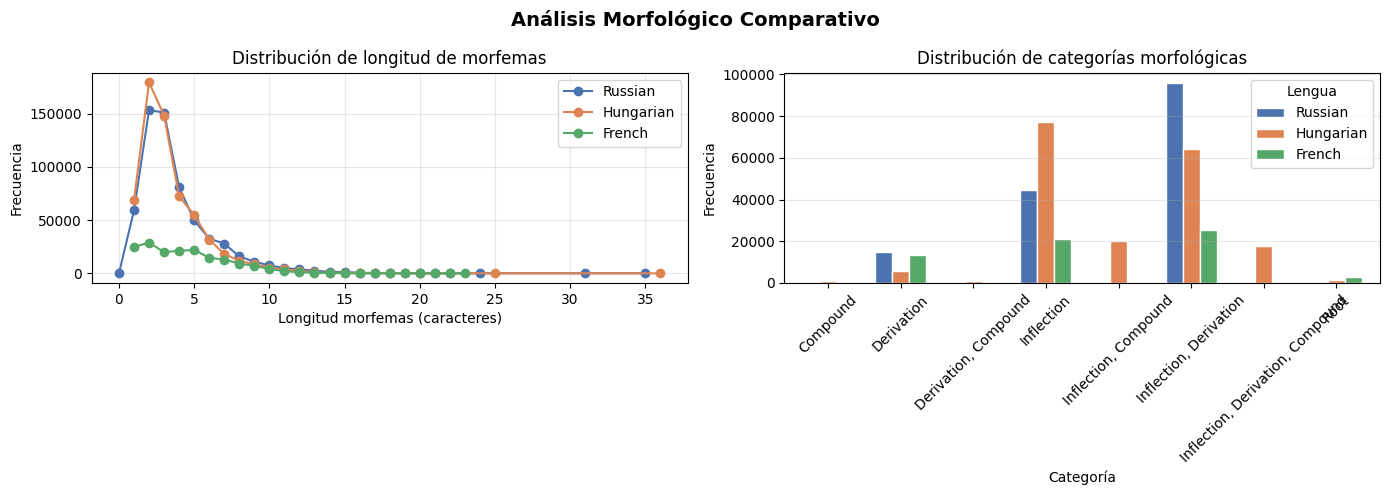

In [14]:
# Pedí ayuda a Claude para generar las gráficas, no soy un experto usando matplot aún

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Análisis Morfológico Comparativo", fontsize=14, fontweight="bold")

colors = {"rus": "#4C72B0", "hun": "#DD8452", "fra": "#55A868"}

# Distribución de longitud de morfemas
ax1 = axes[0]
for code, name in langs_selected.items():
    df = corpora_morph[code]
    # Longitud de cada morfema individual
    morph_lengths = df["morph"].explode().apply(
        lambda m: len(m.replace("@@", "")) # Hay que quitar el @@ para poder ver la longitud real del morfema
    )
    morph_lengths.value_counts().sort_index().plot(
        kind="line",
        ax=ax1,
        label=name,
        color=colors[code],
        marker="o"
    )

ax1.set_title("Distribución de longitud de morfemas")
ax1.set_xlabel("Longitud morfemas (caracteres)")
ax1.set_ylabel("Frecuencia")
ax1.legend()
ax1.grid(alpha=0.3)

# Distribución de categorías
ax2 = axes[1]
category_data = {}
for code, name in langs_selected.items():
    df = corpora_morph[code]
    counts = df["category"].map(CATEGORIES).value_counts()
    category_data[name] = counts

df_cats = pd.DataFrame(category_data).fillna(0)
df_cats.plot(
    kind="bar",
    ax=ax2,
    color=list(colors.values()),
    edgecolor="white",
    width=0.7
)

ax2.set_title("Distribución de categorías morfológicas")
ax2.set_xlabel("Categoría")
ax2.set_ylabel("Frecuencia")
ax2.tick_params(axis="x", rotation=45)
ax2.legend(title="Lengua")
ax2.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("morfologia_comparativa.png", dpi=150, bbox_inches="tight")
plt.show()

### **¿Cuál de las tres lenguas se comporta más como una lengua aglutinante y cuál como una lengua aislante?**

#### **Justifica tu respuesta usando tus métricas y figuras**


### **Repaso de conceptos**

#### **Lengua aglutinante**
Una lengua aglutinante es aquella en la que las palabras se forman
pegando morfemas uno tras otro de forma **transparente y modular**:
cada morfema expresa exactamente **una** categoría gramatical y los
límites entre morfemas son claramente identificables.

Ejemplo en húngaro:
```
ház      +  aim    +  ban
casa     +  mis    +  en
                    = "en mis casas"
```
Cada pieza tiene un significado único y separable.

#### **Lengua aislante**
Una lengua aislante (o analítica) es aquella en la que las palabras
tienden a **no modificarse morfológicamente**: cada palabra equivale
a un morfema y la información gramatical se expresa mediante el
**orden de las palabras

Ejemplo en mandarín:
```
我  昨天  吃  了  饭
yo  ayer  comer  PASADO  arriba
= "Yo comí ayer"
```
El verbo "吃" (comer) no cambia de forma, el tiempo se expresa
con la partícula "了" separada.

#### **Conclusión**
Una lengua aglutinante por lo general debe de cumplir que tendrá una mayor cantidad de morfemas por palabra (μ más alto), mientras que una lengua aislante tendrá menos morfemas por palabra ( μ más bajo )

#### **Respuesta a la pregunta usando los datos obtenidos**

| Lengua  | Morfemas/palabra (μ) | Flexión (%) | Derivación (%) |
|---------|----------------------|-------------|----------------|
| Ruso    | 3.852                   | 28.28%         | 9.49%            |
| Húngaro | 3.230                   | 41.09%         | 2.94%            |
| Francés | 2.669                   | 33.30%         | 21.52%           |

#### Lengua más aglutinante ( la que tenga μ más alto )

El **Ruso** presenta el ratio morfemas/palabra más alto
(μ = 3.852), lo que indica que sus palabras se construyen acumulando
más morfemas.

#### Lengua más aislante: ( la que tenga μ más bajo )

El **francés** presenta el ratio morfemas/palabra más bajo (μ = 2.669),
lo que sugiere que sus palabras tienden a llevar menos morfemas
adheridos. Esto es consistente con su tendencia analítica: el francés
expresa gran parte de su gramática mediante palabras auxiliares
separadas en lugar de un solo verbo conjugado


## **Extra**
***

### **Genera la matriz de confusión para el etiquetador CRFs visto en clase**

Se retoma el modelo CRF entrenado en clase con el corpus `cess_esp`
y generaremos su matriz de confusión para analizar dónde falla el modelo.

In [ ]:
# !uv add nltk scikit-learn sklearn-crfsuite <- Local con uv
!pip install nltk scikit-learn sklearn-crfsuite

In [15]:
# Descargamos el corpus
nltk.download("cess_esp")

[nltk_data] Downloading package cess_esp to /home/ofgm/nltk_data...
[nltk_data]   Package cess_esp is already up-to-date!


True

In [16]:
# Funciones tomadas del notebook de la clase, vitaminadas con comentarios 
# producidos con Claude para facilitar su entendimiento y uso

def get_tags_map() -> dict:
    """sauce https://gist.github.com/vitojph/39c52c709a9aff2d1d24588aba7f8155/
    
    Descarga un archivo de mapeo que convierte etiquetas POS específicas
    del corpus cess_esp (español) al formato universal de etiquetas POS.
    
    El archivo tiene el formato:
        etiqueta_original [TAB] etiqueta_universal
    Por ejemplo:
        vmip3s0 [TAB] VERB
        da0ms0  [TAB] DET
    
    Returns
    -------
    dict
        Diccionario donde las llaves son etiquetas originales (en minúsculas)
        y los valores son etiquetas universales (NOUN, VERB, ADJ, etc.)
    """
    # Descarga el archivo de mapeo desde GitHub y lo divide por líneas
    tags_raw = r.get(
        "https://gist.githubusercontent.com/vitojph/39c52c709a9aff2d1d24588aba7f8155/raw/af2d83bc4c2a7e2e6dbb01bd0a10a23a3a21a551/universal_tagset-ES.map"
    ).text.split("\n")
    
    # Construye el diccionario separando cada línea por tabulador:
    # parte[0] = etiqueta original, parte[1] = etiqueta universal
    tags_map = {line.split("\t")[0].lower(): line.split("\t")[1] for line in tags_raw}
    return tags_map


def map_tag(tag: str, tags_map=get_tags_map()) -> str:
    """Convierte una etiqueta POS del corpus al formato universal utilizando el
    diccionario de mapeo.
    """
    # Caso especial para signos de puntuación: "." → "PUNCT"
    if tags_map.get(tag.lower()) == ".":
        return "PUNCT"
    # Busca la etiqueta en el mapa; si no existe devuelve "N/F"
    return tags_map.get(tag.lower(), "N/F")


def parse_tags(corpora: list[list[tuple]]) -> list[list[tuple]]:
    """Convierte todas las etiquetas del corpus al formato universal.
    
    Recorre cada oración del corpus y reemplaza la etiqueta original
    de cada palabra por su equivalente universal usando map_tag().
    """
    result = []
    for sentence in corpora:
        # Para cada oración, convierte cada par (palabra, tag_original)
        # a (palabra, tag_universal)
        result.append([(word, map_tag(tag)) for word, tag in sentence])
    return result


def word_to_features(sent, i) -> dict:
    """Extrae las características (features) de una palabra en su contexto.
    
    Estas features son las que usa el CRF para aprender a predecir
    etiquetas POS. Capturan información de la palabra actual y
    opcionalmente de la palabra anterior.
    
    Parameters
    ----------
    sent : list[tuple]
        Oración completa como lista de tuplas (palabra, etiqueta)
    i : int
        Índice de la palabra actual dentro de la oración
    
    Returns
    -------
    dict
        Diccionario de features para la palabra en posición i:
        - word.lower(): la palabra en minúsculas
        - word[-3:]:    los últimos 3 caracteres (sufijo largo)
        - word[-2:]:    los últimos 2 caracteres (sufijo corto)
        - prev_word:    la palabra anterior en minúsculas (si existe)
        - BOS:          True si es la primera palabra de la oración
    """
    word = sent[i][0]
    
    # Features de la palabra actual
    # Los sufijos ayudan a identificar morfología
    features = {
        "word.lower()": word.lower(),  # normaliza mayúsculas
        "word[-3:]":    word[-3:],     # sufijo de 3 chars
        "word[-2:]":    word[-2:],     # sufijo de 2 chars
    }
    
    if i > 0:
        # Si no es la primera palabra, agrega la palabra anterior
        # El contexto previo ayuda a desambiguar:
        prev_word = sent[i - 1][0]
        features.update({
            "prev_word.lower()": prev_word.lower(),
        })
    else:
        # Sino, marca el inicio de oración (Beginning Of Sentence)
        # La primera palabra suele tener distribución de tags distinta
        features["BOS"] = True
    
    return features


def sent_to_features(sent) -> list:
    """Extrae las features de todas las palabras de una oración.
    
    Aplica word_to_features() a cada posición de la oración.
    
    Parameters
    ----------
    sent : list[tuple]
        Oración como lista de tuplas (palabra, etiqueta)
    
    Returns
    -------
    list[dict]
        Lista de diccionarios de features, uno por palabra
    """
    # Itera sobre cada posición i de la oración
    return [word_to_features(sent, i) for i in range(len(sent))]


def sent_to_labels(sent) -> list:
    """Extrae únicamente las etiquetas POS de una oración.
    
    Se usa para obtener los valores objetivo (y) durante
    el entrenamiento y evaluación del CRF.
    
    Parameters
    ----------
    sent : list[tuple]
        Oración como lista de tuplas (palabra, etiqueta)
    
    Returns
    -------
    list[str]
        Lista de etiquetas POS en el mismo orden que las palabras
        Ejemplo: ["DET", "NOUN", "VERB", "ADJ"]
    """
    # Extrae solo el segundo elemento (etiqueta) de cada tupla
    return [label for token, label in sent]


In [20]:
corpora = cess_esp.tagged_sents()
corpora = parse_tags(corpora)

In [65]:
# Preparando datos para el CRF
X = [sent_to_features(sent) for sent in corpora]
y = [sent_to_labels(sent) for sent in corpora]

In [66]:
# Exploración de data estructurada
print("Entrada:", X[0][0])
print("Salida:", y[0][0])

Entrada: {'word.lower()': 'el', 'word[-3:]': 'El', 'word[-2:]': 'El', 'BOS': True}
Salida: DET


In [67]:
# Separando en dos conjuntos, uno para entrenamiento y otro para pruebas
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [68]:
# Inicializar y entrenar el CRF tagger
crf = CRF(
    algorithm="lbfgs",
    c2=0.001,
    max_iterations=10,
    verbose=True,
)
try:
    crf.fit(X_train, y_train)
except AttributeError as e:
    print(e)

loading training data to CRFsuite: 100%|██| 4824/4824 [00:01<00:00, 4497.15it/s]



Feature generation
type: CRF1d
feature.minfreq: 0.000000
feature.possible_states: 0
feature.possible_transitions: 0
0....1....2....3....4....5....6....7....8....9....10
Number of features: 64610
Seconds required: 0.262

L-BFGS optimization
c1: 0.000000
c2: 0.001000
num_memories: 6
max_iterations: 10
epsilon: 0.000010
stop: 10
delta: 0.000010
linesearch: MoreThuente
linesearch.max_iterations: 20

Iter 1   time=0.40  loss=212079.86 active=64610 feature_norm=5.00
Iter 2   time=0.13  loss=143141.29 active=64610 feature_norm=10.50
Iter 3   time=0.13  loss=112380.00 active=64610 feature_norm=15.10
Iter 4   time=0.13  loss=97209.12 active=64610 feature_norm=17.37
Iter 5   time=0.14  loss=79551.54 active=64610 feature_norm=22.97
Iter 6   time=0.13  loss=70466.40 active=64610 feature_norm=29.44
Iter 7   time=0.13  loss=63740.86 active=64610 feature_norm=33.41
Iter 8   time=0.13  loss=56958.48 active=64610 feature_norm=40.80
Iter 9   time=0.13  loss=53006.59 active=64610 feature_norm=48.05
Iter

In [69]:
y_pred = crf.predict(X_test)

# Flatten the true and predicted labels
y_test_flat = [label for sent_labels in y_test for label in sent_labels]
y_pred_flat = [label for sent_labels in y_pred for label in sent_labels]

# Evaluate the model
report = classification_report(y_true=y_test_flat, y_pred=y_pred_flat)
rprint(report)

/home/ofgm/Documentos/Linguistica/cl-2026-2-lab/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ofgm/Documentos/Linguistica/cl-2026-2-lab/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/ofgm/Documentos/Linguistica/cl-2026-2-lab/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

precision    recall  f1-score   support

         ADJ       0.63      0.67      0.65      2675
         ADP       0.98      0.99      0.98      6577
         ADV       0.88      0.66      0.75      1473
        CONJ       0.91      0.89      0.90      2149
         DET       0.95      0.94      0.95      5563
        NOUN       0.81      0.88      0.85      9005
         NUM       0.49      0.28      0.36       400
        PRON       0.81      0.72      0.76      1705
       PUNCT       1.00      0.99      0.99      4820
        VERB       0.90      0.88      0.89      4505
           X       0.00      0.00      0.00         4

    accuracy                           0.89     38876
   macro avg       0.76      0.72      0.73     38876
weighted avg       0.89      0.89      0.88     38876

#### **Matriz de confusión**

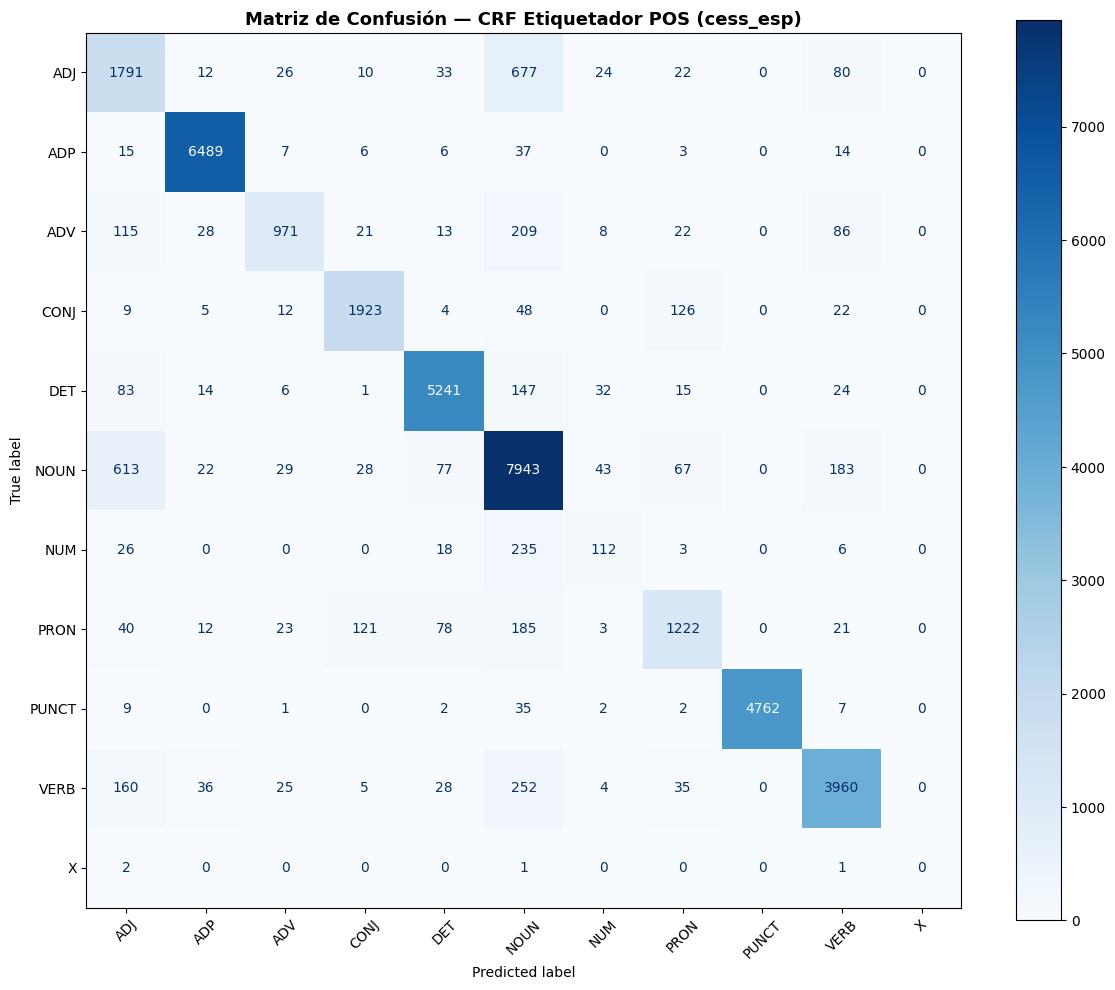

In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Obtener las etiquetas únicas en el orden correcto
labels = sorted(set(y_test_flat))

# Calcular la matriz de confusión
cm = confusion_matrix(y_test_flat, y_pred_flat, labels=labels)

# Visualizar
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(
    ax=ax,
    cmap="Blues",
    colorbar=True,
    xticks_rotation=45
)

ax.set_title("Matriz de Confusión — CRF Etiquetador POS (cess_esp)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix_crf.png", dpi=150, bbox_inches="tight")
plt.show()

#### **Observando las etiquetas donde el modelo falló responde ¿Por qué crees que se confundió?**

#### Hipótesis sobre los errores en la clasificación de categorías

1. **ADJ → NOUN y NOUN → ADJ (+1000 casos)**  
   El modelo etiqueta adjetivos como sustantivos con mucha frecuencia. Quiero creer que la razón principal es que, en español, ambas categorías comparten sufijos casi idénticos:  
   - `-ado`, `-al`, `-nte`, `-oso`.  

   Además, el español permite que un adjetivo funcione como sustantivo sin cambiar su forma, por ejemplo:  
   - *"el importante"*, *"los heridos"*.  

   Tiene sentido que el modelo, sin acceso a contexto sintáctico más amplio, no pueda resolver esta ambigüedad.

2. **ADV → NOUN (209 casos)**  
   Adverbios como *"más"*, *"menos"* o *"bien"* aparecen en contextos donde el modelo los puede confundir con sustantivos o adjetivos.  
   De nuevo, el problema es que los sufijos no ayudan a distinguirlos y el modelo solo observa la palabra anterior para hacer la clasificación.

3. **VERB → NOUN (252 casos)**  
   Formas como *"gobierno"*, *"control"*, *"cambio"* son idénticas entre verbo conjugado y sustantivo. Sin suficiente contexto previo, el modelo no puede resolver esta ambigüedad.

4. **NUM → NOUN (235 casos)**  
   Los números escritos como palabras, como *"cien"*, *"mil"*, *"dos"*, son morfológicamente indistinguibles de sustantivos.

#### Conclusiones
Generalizando:
1. Ventana de contexto es muy pequeña, solo miramos la palabra anterior.
2. Ambigüedad morfológica del español, muchas palabras son idénticas en forma pero distintas en función (ADJ/NOUN, PRON/CONJ, VERB/NOUN).
3. Desbalance de clases — algunos pares de clases puede que tengan muy pocos ejemplos y el modelo apenas los aprende.

#### **¿Es un problema de ambigüedad léxica (la palabra tiene múltiples etiquetas)?**

Sí hay ambigüedad léxica, una misma forma ortográfica tiene más de una categoría gramatical posible según el contexto tal y como lo vemos en la matriz.

Un CRF puede resolver ambigüedad léxica, pero solo ocurre si tiene suficientes features del contexto. El problema con el modelo usado no es que la ambigüedad sea irresoluble sino que las features que usa (sufijos + palabra anterior) son insuficientes para desambiguar estos casos. Un humano resuelve "el gobierno aprobó" vs "yo gobierno bien" de inmediato porque procesa toda la oración pero nuestro modelo solo ve la palabra inmediatamente anterior y eso no alcanza para los pares más problemáticos del corpus.

Entonces, sí es ambigüedad léxica, pero tambien el modelo no tiene el contexto necesario para resolverla.

#### **¿Qué features añadirías para solucionarlo?**

#### **Aumentar el contexto vecinal**
   
El modelo actual solo mira la palabra anterior, considero que añadir la palabra siguiente ayudaría enormemente, especialmente para pares como PRON/CONJ, porque "que leí" vs "que vendría" se distingue por lo que viene después, no antes. Tambien podríamos extender la ventana de palabras anteriores a la actual para que revise las dos anteriores.



#### **Otorgar una morfología más rica**
Podriamos capturar sufijos más largos ya que de momento solo capturamos sufijos de longitud 2 y 3. Así mismo deberíamos capturar prefijos tambien. Adicionalmente, se me ocurre que tambien podríamos agregar a los features los sufijos de las palabras anteriores y prefijos de las palabras que siguen

#### **Aumentar el tamaño del corpus**
Si queremos capturar features más específicas entonces tambien es conveniente aumentar el tamaño del corpus de ser posible para poder 
tener más ejemplos propios de cada clase o feature